# Here we inspect intracranial EEG bandpower interpolation
Please refer to notebook `get_ieeg_data` for how the data was generated

In [1]:
import sys
sys.path.append('../')

from config import *
from figs_config import *

Loaded aesthetics module


## Data specs

In [2]:
fbands = ["delta", "theta", "alpha", "beta", "gamma1", "gamma2"]
space = "fsLR-4k"
strategy = "all"
percentage = "100"

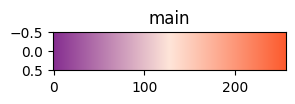

In [3]:
purple = plt.cm.BuPu(0.8)
yellow = plt.cm.Reds(0.1)
orange = plt.cm.YlOrRd(0.6)

ppy, _ = three_colours_gradient(lo=purple, mid=yellow, hi=orange, plot=False)
show_colour_scheme(ppy, "main")

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get an existing colormap and sample a segment
band_colours = plt.cm.plasma(np.linspace(0.1, 0.8, len(fbands)))
sns.color_palette(band_colours)

[(0.254627, 0.013882, 0.615419),
 (0.477344, 0.00698, 0.659549),
 (0.669845, 0.142992, 0.582154),
 (0.816144, 0.302368, 0.451816),
 (0.923287, 0.463251, 0.332801),
 (0.98826, 0.652325, 0.211364)]

# 1. Sparse to continuous

# 2. Variography

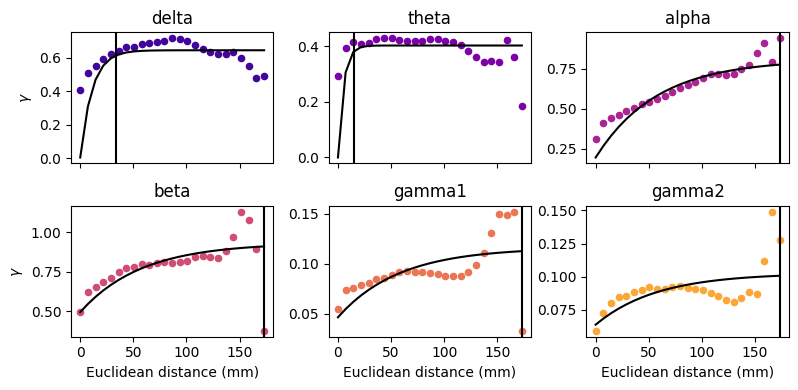

In [54]:
from interpmodules import helpers, metrics
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import zscore

fig, axs = plt.subplots(2,3, figsize = (8, 4), sharex=True)

variogram_gof = dict.fromkeys(fbands)

for fi, fband in enumerate(fbands):

    row, col = fi // 3, fi % 3
    maptag = f"{fband}_no_outlier"
    datasource = f"ieeg-{fband}-pet"    
    results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')
    x,y,N,eff_range,psill,nugg = results['variogram']
    
    fit = [ helpers.exponential(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]

    joined = np.concat([y,fit])
    rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
    rescaled_y = rescaled[:len(x)]
    rescaled_fit = rescaled[len(x):]
    variogram_gof[fband] = np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual'))

    axs[row,col].scatter(x,y, color=band_colours[fi], s=20)
    axs[row,col].plot(x, fit, c='k')
    axs[row, col].axvline(eff_range, c = 'k')
    axs[row,col].set_title(fband)
    axs[1, col].set_xlabel("Euclidean distance (mm)")
    axs[row,0].set_ylabel(r"$\gamma$")
plt.tight_layout()
plt.savefig(projdir + "/figs/main/use_case_ieeg_variograms.svg")
#plt.show()

In [7]:
import joblib
from interpmodules import helpers
src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-alpha-pet.pkl')
sampling = helpers.cv_random_noreplace(pvdata=src_pvdata, nfolds=5, rseed=321)

167


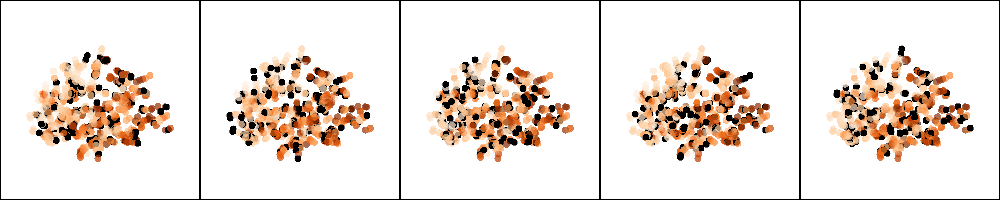

In [112]:
import pyvista as pv

pl = pv.Plotter(shape=(1,5), window_size = (1000,200))

for i in range(5):
    pl.subplot(0,i)
    pl.add_points(pv.PolyData(sampling[0][i]).rotate_z(180), scalars = src_pvdata['alpha_zscored_no_outlier'][sampling[1][i]], \
              cmap = 'Oranges', point_size = 7, opacity = .7, show_scalar_bar=False, **point_aes)
    pl.add_points(pv.PolyData(sampling[2][i]).rotate_z(180), point_size = 7, color = 'k', opacity = 1, **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_ieeg_random_cv_examples_alpha.svg')

In [8]:
import joblib

# load dsk centroids
ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')

# re-register them to icbm09
mni_cents = fslr_to_mni_coords_transform(coords = ctx_dsk33[2], inverse=True)

In [9]:
j=2
sampling = helpers.cv_distdep_noreplace(pvdata=src_pvdata, center = mni_cents[j,:], nfolds=5, rseed=321)

In [10]:
sampling[2][0].shape

(167, 3)

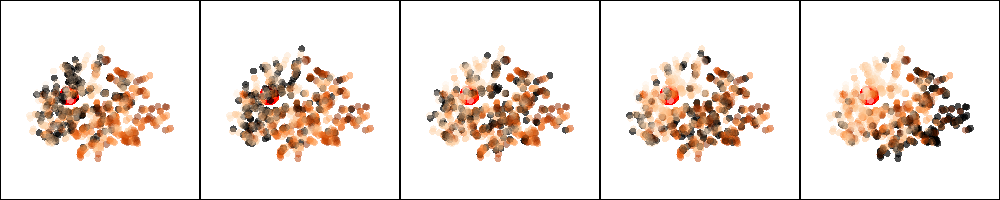

In [16]:
import pyvista as pv

pl = pv.Plotter(shape=(1,5), window_size = (1000,200))

for i in range(5):
    pl.subplot(0,i)
    pl.add_points(pv.PolyData(sampling[0][i]).rotate_z(180), scalars = src_pvdata['alpha_zscored_no_outlier'][sampling[1][i]], \
              cmap = 'Oranges', point_size = 7, opacity = .5, show_scalar_bar=False, **point_aes)
    pl.add_points(pv.PolyData(sampling[2][i]).rotate_z(180), point_size = 7, color = 'k', opacity = .7, **point_aes)
    pl.add_points(pv.PolyData(mni_cents[j,:]).rotate_z(180), point_size = 20, color='red', **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_intracranial_cv_sample_example.svg')

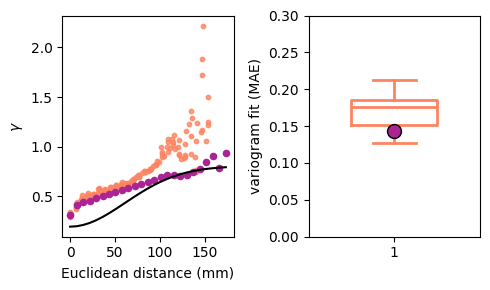

In [143]:
fband = 'alpha'

variogram_gof_emp = []
variogram_gof_cv = []

fig, axs = plt.subplots(1,2, figsize = (5,3))

maptag = f"{fband}_no_outlier"
datasource = f"ieeg-{fband}-pet"    
results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')
x,y,N,eff_range,psill,nugg = results['variogram']

fit = [ helpers.gaussian(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]

joined = np.concat([y,fit])
rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
rescaled_y = rescaled[:len(x)]
rescaled_fit = rescaled[len(x):]
variogram_gof_emp = np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual'))

axs[0].scatter(x,y, color=band_colours[2], s=20, zorder = 5)
for i in range(5):
    X = sampling[0][i]
    train_vals = src_pvdata['alpha_zscored_no_outlier'][sampling[1][i].astype(int)]
    D = helpers.internal_distance_matrix(X, 'euclidean')
    vario =  helpers._get_empirical_variogram(x=train_vals ,D=D,nh=25,h_bounds=0)

    joined = np.concat([vario[1],fit])
    rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
    rescaled_y = rescaled[:len(x)]
    rescaled_fit = rescaled[len(x):]
    variogram_gof_cv.append( np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual')) )

    
    axs[0].scatter(vario[0], vario[1], color=ppy(0.85), s=10, alpha = 0.8)
axs[0].plot(x, fit, c='k', zorder = 10)
#axs.axvline(eff_range, c = 'k')
axs[0].set_xlabel("Euclidean distance (mm)")
axs[0].set_ylabel(r"$\gamma$")

axs[1].boxplot(variogram_gof_cv, widths = 0.5, \
            medianprops=dict(color=ppy(0.85), linewidth=2),\
           whiskerprops=dict(color=ppy(0.85), linewidth=2),\
           capprops=dict(color=ppy(0.85), linewidth=2),\
           boxprops=dict(color=ppy(0.85), linewidth=2))
axs[1].scatter(x=1, y=variogram_gof_emp, color = band_colours[2], edgecolor = 'k', s=100, zorder = 10)
axs[1].set_ylim([0,0.3])
axs[1].set_xlabel('')
axs[1].set_ylabel('variogram fit (MAE)')

plt.tight_layout()
#plt.show()
#plt.savefig(projdir + '/figs/main/cv_variogram_and_fit.svg')

In [144]:
variogram_gof_plotdata = pd.DataFrame(variogram_gof.values(), index = variogram_gof.keys())

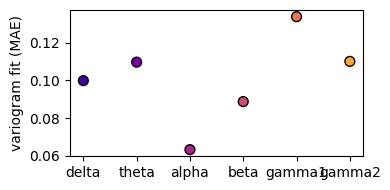

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (4,2))
    
plt.scatter(y=variogram_gof_plotdata, s=50, edgecolor = 'k',x=variogram_gof_plotdata.index, c=band_colours)
plt.ylabel("variogram fit (MAE)")
#plt.show()
plt.tight_layout()
plt.savefig(projdir + '/figs/main/use_case_ieeg_fbands_variogram_fit.svg')

# 3. Interpolated maps

In [5]:
mesh_aes = {"show_scalar_bar": False,\
            "smooth_shading": True,\
            "specular": 0, "diffuse":0, "ambient":1}
point_aes = {"opacity": .7, "render_points_as_spheres": True, "diffuse":0, "ambient":1,"specular":0}

In [6]:
import joblib
reduced_mesh = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

Maximum number of clients reached
2026-01-16 17:10:02.258 (   4.042s) [    7F2606335B80]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=:1
Maximum number of clients reached


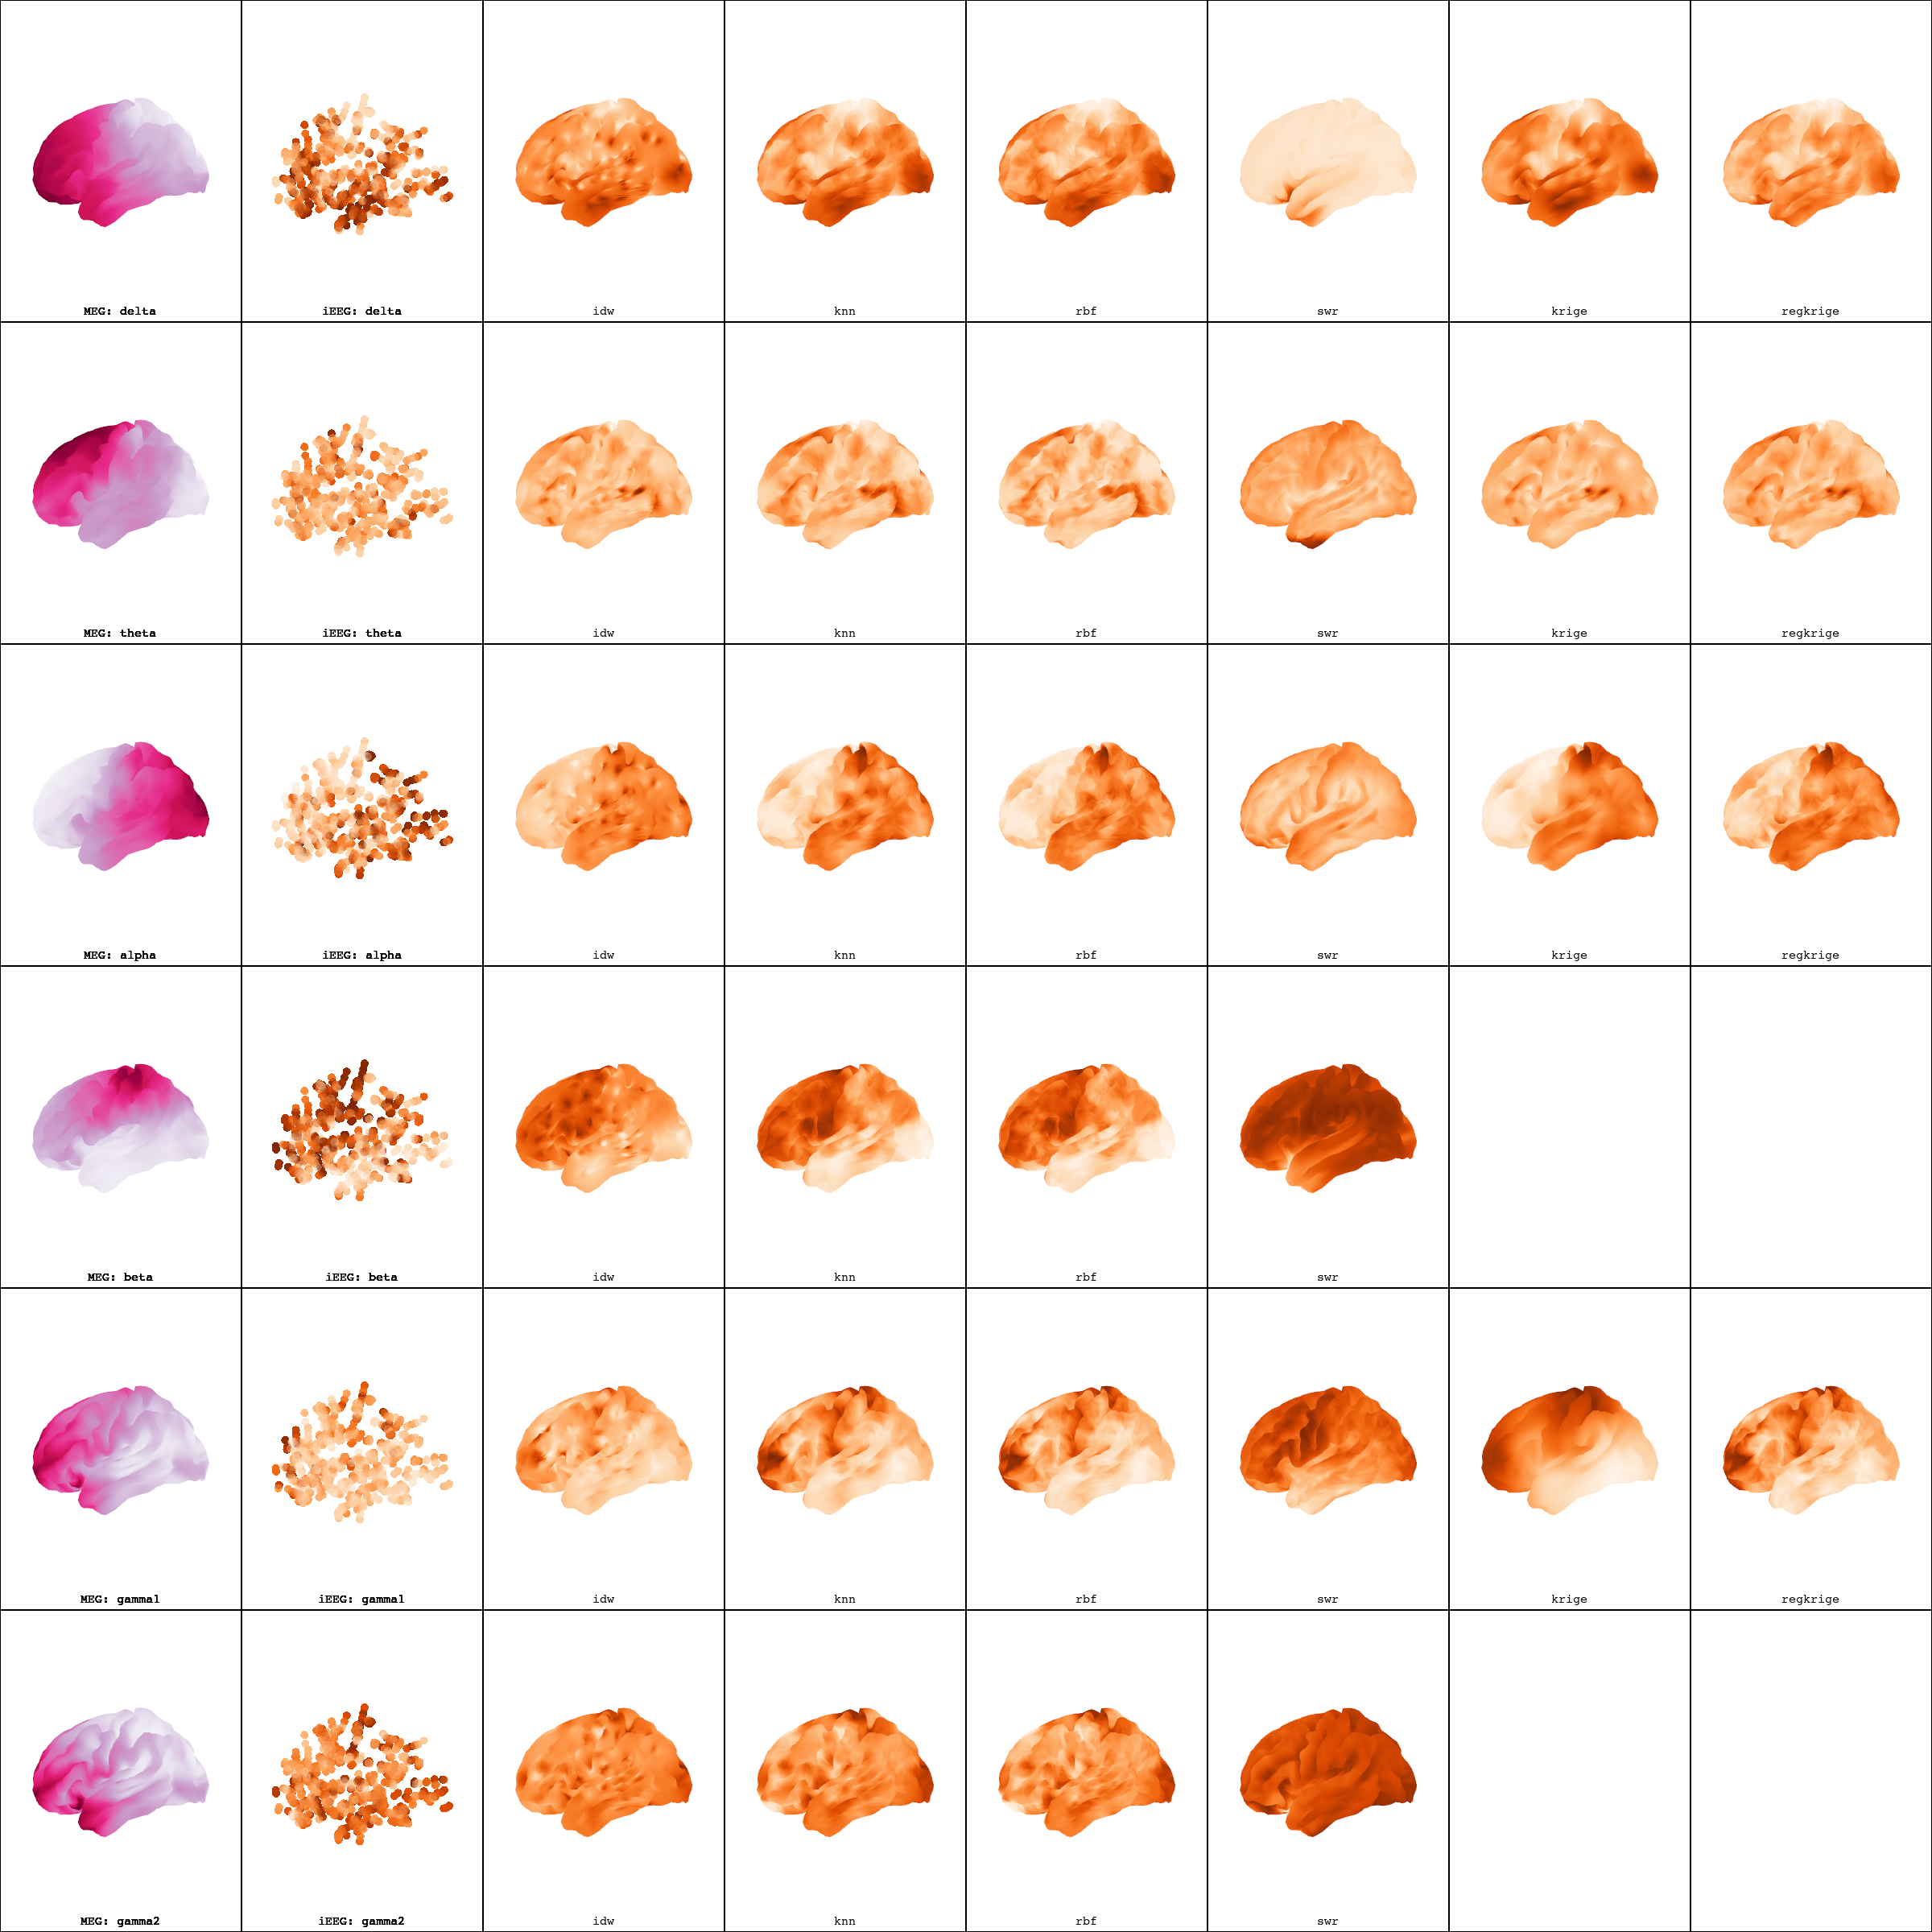

In [7]:
import pyvista as pv

pl = pv.Plotter(shape = (len(fbands), len(approaches) + 2), window_size = (2400, 2400))

for fi, fband in enumerate(fbands):

    compare_maptag = f'hcps1200_meg{fband}'
    
    maptag = f"{fband}_no_outlier"
    datasource = f"ieeg-{fband}-pet"
    src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
    results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')
    for ai, approach in enumerate(approaches):

        pl.subplot(fi, 0)
        pl.add_mesh(reduced_mesh.rotate_z(180), scalars = compare_maptag, cmap = "PuRd", **mesh_aes)
        pl.add_text(f"MEG: {fband}", position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"

        pl.subplot(fi, 1)
        pl.add_points(src_pvdata.rotate_z(180), scalars = f"{fband}_zscored_no_outlier", cmap = "Oranges", \
                      point_size = 10, show_scalar_bar=False, **point_aes)
        pl.add_text(f"iEEG: {fband}", position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"
        
        pl.subplot(fi, ai + 2)
        if not isinstance(results['interpolated'][approach], np.ndarray): continue
        pl.add_mesh(reduced_mesh.rotate_z(180), scalars = results['interpolated'][approach], cmap = "Oranges", **mesh_aes)
        pl.add_text(approach, position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"
        
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_ieeg_interpolated.svg')

# Showcase the alpha band

In [7]:
point_aes = {"opacity": .7, "render_points_as_spheres": True, "diffuse":0, "ambient":1,"specular":0}

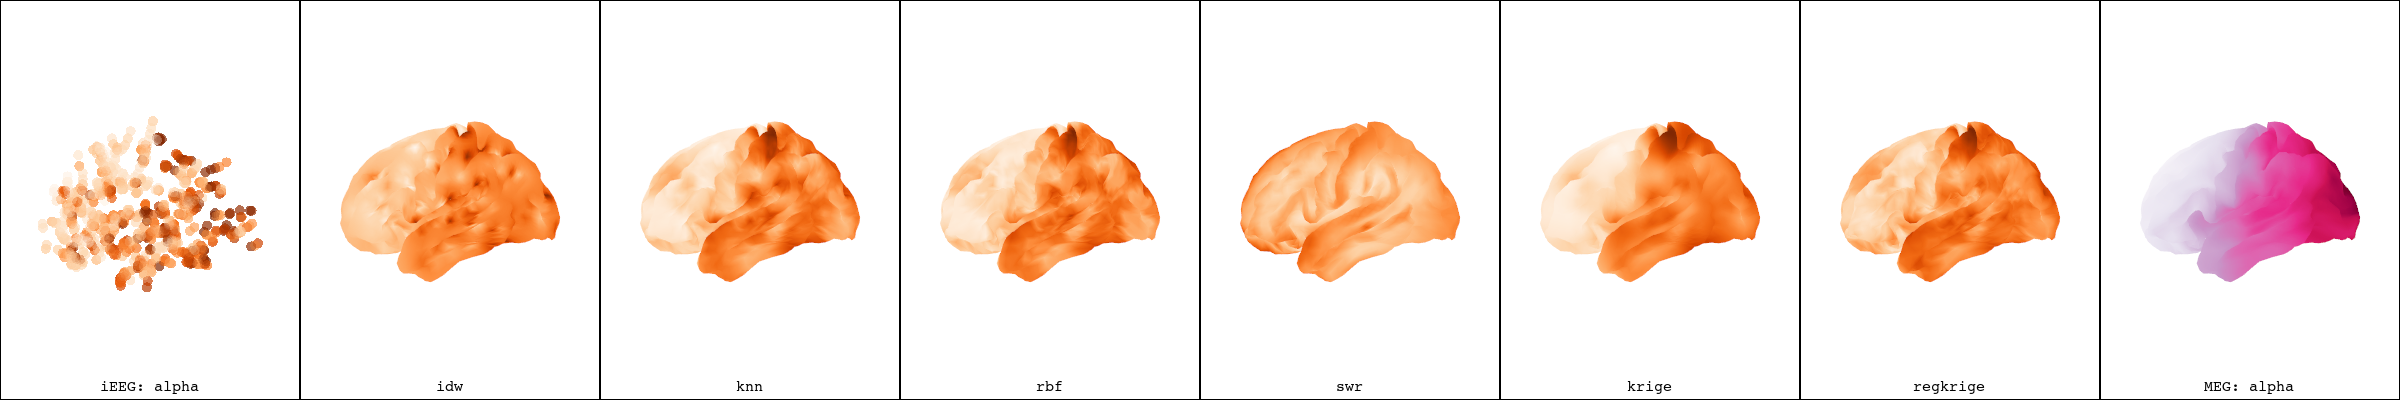

In [9]:
import pyvista as pv

fband = 'alpha'
compare_maptag = f'hcps1200_meg{fband}'

corr = dict.fromkeys(approaches)
    
maptag = f"{fband}_no_outlier"
datasource = f"ieeg-{fband}-pet"
src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')

pl = pv.Plotter(shape = (1,len(approaches) + 2), window_size = (2400, 400))

pl.subplot(0,0)
pl.add_points(src_pvdata.rotate_z(180), scalars = f"{fband}_zscored_no_outlier", cmap = "Oranges", \
                      point_size = 10, show_scalar_bar=False, **point_aes)
pl.add_text(f"iEEG: {fband}", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

pl.subplot(0,7)
pl.add_mesh(reduced_mesh.rotate_z(180), scalars = compare_maptag, cmap = "PuRd", **mesh_aes)
pl.add_text(f"MEG: {fband}", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

for ai, approach in enumerate(approaches):
    pl.subplot(0,ai + 1)
    if not isinstance(results['interpolated'][approach], np.ndarray): continue
    pl.add_mesh(reduced_mesh.rotate_z(180), scalars = results['interpolated'][approach], cmap = "Oranges", **mesh_aes)
    pl.add_text(approach, position = "lower_edge", font = "courier", font_size = 7)

    corr[approach] = np.corrcoef( results['interpolated'][approach], reduced_mesh[compare_maptag] )[1,0]
    
    pl.camera_position = "yz"

pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_ieeg_alpha.svg')

# Spatial nulls

In [8]:
from interpmodules import helpers

D = helpers.internal_distance_matrix(v=reduced_mesh.points, f=None, method = 'euclidean', n_proc = -1)

In [9]:
from brainspace.null_models import MoranRandomization

In [11]:
msr = MoranRandomization(n_rep=1000, procedure='singleton', tol=1e-6,
                         random_state=321)
msr.fit(D)

MoranRandomization(n_rep=1000, random_state=321, tol=1e-06)

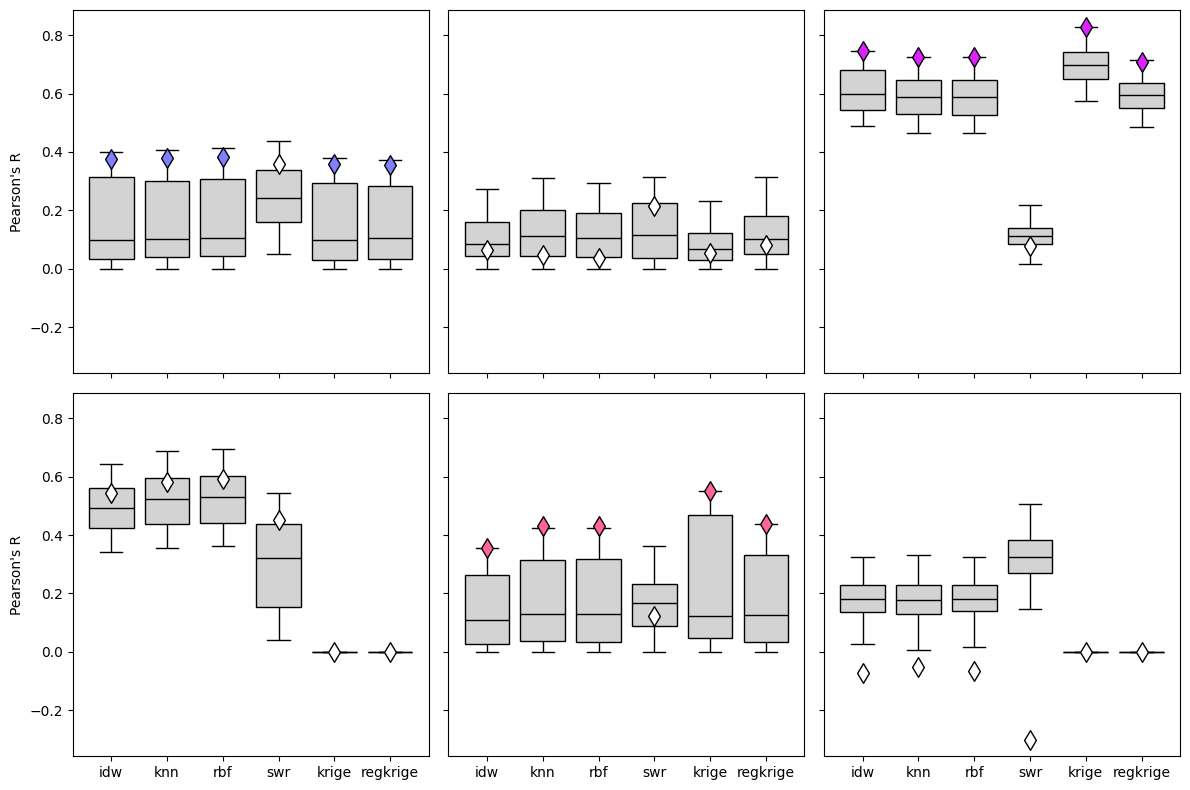

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot = False

fig, axs = plt.subplots(2,3, figsize = (12, 8), sharey=True, sharex=True)


for fi, fband in enumerate(fbands):

    row = fi // 3
    col = fi % 3
    
    emp_r = dict.fromkeys(approaches)
    pvals = dict.fromkeys(approaches)
    all_nulldistr = dict.fromkeys(approaches)

    compare_maptag = f'hcps1200_meg{fband}'

    maptag = f"{fband}_no_outlier"
    datasource = f"ieeg-{fband}-pet"
    src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_ieeg-{fband}-pet.pkl')
    results = joblib.load(projdir + f'/results/standard-consensus/ieeg/{space}_{maptag}_volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')

    if plot:
        # null distribution histograms
        fig1, axs1 = plt.subplots(2,3, figsize = (8,3))
    for ai, approach in enumerate(approaches):

        if plot: row, col = ai // 3, ai % 3

        dt = results['interpolated'][approach]
        if not isinstance(results['interpolated'][approach], np.ndarray): emp_r[approach] = 0; pvals[approach] = 1; all_nulldistr[approach] = np.zeros(1000); continue
        else: emp_r[approach] = np.corrcoef( results['interpolated'][approach].flatten(), reduced_mesh[compare_maptag] )[1,0]
        
        mrnulls = msr.randomize(dt)
        nulldistr = [ abs(np.corrcoef( mrnulls[i,:], reduced_mesh[compare_maptag]) )[1,0] for i in range(1000)]
        all_nulldistr[approach] = np.array(nulldistr)
        
        pvals[approach] = np.mean(np.abs(nulldistr) >= np.abs(emp_r[approach]))

        if plot:
            axs1[row, col].set_title(approach)
            axs1[row, col].hist(nulldistr, facecolor = 'lightgray', bins = 25)
            axs1[row, col].axvline(emp_r[approach], color = band_colours[fbands.index(fband)])
            
    if plot:
        plt.tight_layout()
        plt.savefig(projdir + f'/figs/main/use_case_ieeg_compare_meg_{fband}_histograms.svg')
        plt.close(fig1)
    
    nulldistr_plotdata = pd.DataFrame(all_nulldistr)
    df = pd.DataFrame([emp_r, pvals], index = ['r', 'p'])
    df = df.T
    is_significant = df['p'] < .05

    sns.boxplot(nulldistr_plotdata, linecolor = 'k', color = 'lightgray', ax=axs[row, col])
    axs[row, col].scatter(
        df.index[~is_significant],
        df['r'][~is_significant],
        color="w",
        marker = 'd',
        edgecolor = 'k',
        s=100,
        zorder=5,
        label="Not significant"
    )
    axs[row, col].scatter(
        df.index[is_significant],
        df['r'][is_significant],
        color=band_colours[fbands.index(fband)],
        marker = 'd',
        edgecolor = 'k',
        s=100,
        zorder=5,
        label="Significant"
    )
    axs[row, 0].set_ylabel("Pearson's R")

    joblib.dump((df, nulldistr_plotdata), projdir + f'/results/use_case_ieeg_{fband}_nulldistr.pkl')
plt.tight_layout()
plt.savefig(projdir + f'/figs/main/use_case_ieeg_compare_meg_moran_nulls_boxplot.svg')

In [114]:
df, nulldistr = joblib.load(projdir + '/results/use_case_ieeg_alpha_nulldistr.pkl')

In [115]:
df = df.sort_values(by = 'r', ascending = False)

In [116]:
df

,r,p
krige,0.829812,0.000
idw,0.744660,0.001
knn,0.726883,0.000
rbf,0.726127,0.001
regkrige,0.708881,0.003
swr,0.077759,0.812


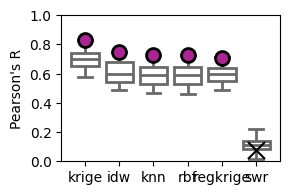

In [140]:
import seaborn as sns

is_significant = df['p'] < .05

fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(nulldistr, order = df.index, linecolor = 'dimgray', linewidth = 2, color = 'w', ax=ax)
ax.scatter(
    df.index[~is_significant],
    df['r'][~is_significant],
    marker = 'x',
    s=150,
    color='k',
    zorder=5,
    label="Not significant"
)
ax.scatter(
    df.index[is_significant],
    df['r'][is_significant],
    color=band_colours[fbands.index('alpha')],
    marker = 'o',
    edgecolor = 'k',
    s=100,
    zorder=5,
    linewidth = 2,
    label="Significant"
)
ax.set_ylabel("Pearson's R")
plt.tight_layout()
plt.ylim([0,1])
plt.show()
#plt.savefig(projdir + '/figs/main/use_case_ieeg_alpha_spatialnulls.svg')